# Laboratory work 2

## Modeling continuous radnom variable

Distribution density: $$f(x)=\frac{1}{x\ln 5},\ \ [1; 5]$$ Distribution function: $$F(x)=\begin{cases}0,\ \ x \le 1 \\ \int^x_1 f(y) dy = \frac{\ln x}{\ln 5}=\log_5 x ,\ \ 1 \le x \le 5\\ 0, \ \ x > 5 \end{cases}$$ Inverse distribution function: $$F^{-1}(x) = 5^{x}$$

> Theorem
>
> If $\alpha$ - basic random variable, $\xi$ - simulated random variable, $F(x)$ - distribution function, 
>then $\xi=F^{-1}(\alpha)$.

Importing standart libraries, setting constants and declaring distribution functions:

In [26]:
import math
from random import random
from typing import Callable

GENERATED_NUMBER = 1000

def distribution_density(x: float)->float:
    return 1 / math.log(5) / x

def distribution_function(x: float)->float:
    if x < 1: return 0
    if x > 5: return 1
    
    return 1 / math.log(5) * math.log(x)

def inverse_distribution_function(x: float)->float:
    return 5 ** x

Generating basic random variables and required random variables:

In [27]:
basic_random_variables: list[float] = [random() for _ in range(GENERATED_NUMBER)]
sample: list[float] = [inverse_distribution_function(x) for x in basic_random_variables]

## Conducting test inspection of generator:

Getting estimated mean ans variance and comparing them with theoritical:
$$E\{\xi \} = \int^5_1 x f(x) dx = \int^5_1 \frac{1}{\ln 5} dx = \frac{4}{\ln 5} \approx 2.48534$$
$$V\{\xi \} = E\{\xi^2 \} - (E\{\xi \})^2 = \int^5_1 x^2 f(x) dx - \frac{16}{(\ln 5)^2} = \int^5_1 \frac{x}{\ln 5}dx - \frac{16}{(\ln 5)^2} = \frac{12}{\ln 5} - \frac{16}{(\ln 5)^2} \approx 1.27911$$

In [28]:
def mean(sample: list[float])->float:
    return sum(sample) / len(sample)

def variance(sample: list[float])->float:
    sample_mean = mean(sample)
    return sum((x - sample_mean) ** 2 for x in sample) / (len(sample)-1)

mean_estimated = mean(sample)
variance_estimated = variance(sample)

print(mean_estimated)
print(variance_estimated)

2.5587324609078093
1.3497682426988833


Constructing a confidence interval for mean:

In [29]:
from scipy.stats import norm
epsilon: float = 0.05
s1: float = mean_estimated - math.sqrt(variance_estimated / len(sample)) * float(norm.ppf(1 - epsilon / 2))
s2: float = mean_estimated + math.sqrt(variance_estimated / len(sample)) * float(norm.ppf(1 - epsilon / 2))

print(f"[{s1}, {s2}]")

[2.486724967396311, 2.6307399544193073]


Testing the hypothesis $\chi^2$:

In [33]:
from scipy.stats import chi2
import numpy as np

def get_statistic_chi_square(sample: list[float], pdf: Callable[[float], float]) -> float:
    n = len(sample)
    bins_num = int(1 + 3.32 * math.log10(n))
    x_min = min(sample)
    x_max = max(sample)
    bin_len = (x_max - x_min) / bins_num
    observed = [0] * bins_num

    for x in sample:
        idx = int((x - x_min) // bin_len)
        if idx == bins_num:
            idx = bins_num - 1
        observed[idx] += 1

    chi2 = 0.0
    for i in range(bins_num):
        left = x_min + i * bin_len
        right = left + bin_len
        center = (left + right) / 2
        expected = n * pdf(center) * bin_len

        if expected > 0:
            chi2 += (observed[i] - expected) ** 2 / expected

    return chi2
    

chi = get_statistic_chi_square(sample, distribution_density)
bins_num = int(1 + 3.32 * math.log10(len(sample))) - 1
chi_square_critical = chi2.isf(0.05, bins_num)
print(chi)
print(chi_square_critical)

8.099343138816389
16.91897760462045


Testing the hypothesis $\omega^2$:

In [31]:


def omega_square_criterium(sample: list[float], cdf: Callable[[float], float])->float:
    statistic: float = 0
    n: int = len(sample)
    for i, x in enumerate(sample):
        statistic += (cdf(x) - (2 * i - 1) / (2 * n)) ** 2
    statistic += 1 / 12 / n
    return statistic

sample.sort()
omega = omega_square_criterium(sample, distribution_function)
print(omega)
0.4614

0.40947516590595073


0.4614

Building distribution function plot and sample histogram:

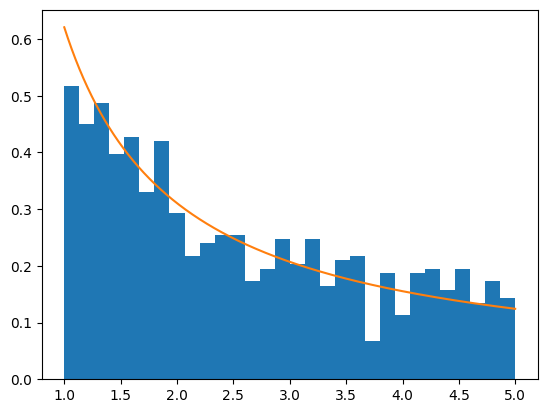

In [32]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(min(sample), max(sample), 10000)
y = [distribution_density(i) for i in x]

plt.hist(sample, bins=30, density=True)
plt.plot(x, y)
plt.show()